<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Detec%C3%A7%C3%A3o_Emo%C3%A7%C3%A3o_Arquitetura_Pratica_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tf_keras

In [2]:
#bibliotecas e importaçoes
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import zipfile
import itertools
import tf_keras as keras
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model, model_from_json
from sklearn.metrics import confusion_matrix

In [3]:
%tensorflow_version 2.x
import tensorflow
tensorflow.__version__

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


'2.20.0'

In [4]:
# montado o gogle drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [5]:
# extrai o material principal
path = "/content/gdrive/My Drive/Material.zip"
zip_object = zipfile.ZipFile(file=path, mode="r")
zip_object.extractall('./')
zip_object.close()
base_imgs = 'Material/fer2013.zip'
zip_object = zipfile.ZipFile(file=base_imgs, mode='r')
zip_object.extractall('./')
zip_object.close()

In [6]:
data = pd.read_csv('fer2013/fer2013.csv') # carrega o dataset com as imagens e emoções

print(f'{len(data)}') # mostra quantas imagens existem no total
print(f'{data.columns.tolist()}')
data.tail() # exibe as últimas linhas para verificar a estrutura

35887
['emotion', 'pixels', 'Usage']


,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


In [7]:
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]

In [8]:
pixels = data['pixels'].tolist()
largura, altura = 48, 48
faces = []
amostras = 0
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')]
    face = np.asarray(face).reshape(largura, altura)
    faces.append(face)

In [9]:
faces = np.asarray(faces)
faces = np.expand_dims(faces, -1)
def normalizar(x):
    x = x.astype('float32')
    x = x / 255.0
    return x
faces = normalizar(faces)
emocoes = pd.get_dummies(data['emotion']).values
print(f'{faces.shape}')
print(f'{emocoes.shape}')

(35887, 48, 48, 1)
(35887, 7)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(faces, emocoes, test_size=0.1, random_state=42)
_, X_val, _, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=41)

print(f'treino: {len(X_train)}')
print(f'validação: {len(X_val)} ')
print(f'teste: {len(X_test)}')

treino: 32298
validação: 3230 
teste: 3589


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Activation
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

num_features = 64 # número base de filtros
num_labels = 7 # 7 emoções possíveis na saída
batch_size = 64
epochs = 100
width, height = 48, 48

model = Sequential()

# extrai bordas e texturas simples
model.add(Conv2D(num_features, kernel_size=(3,3), activation='relu',
                 input_shape=(width, height, 1), data_format='channels_last',
                 kernel_regularizer=l2(0.01)))
model.add(Conv2D(num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization()) # normaliza as ativações pra estabilizar
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2))) # reduz pela metade
model.add(Dropout(0.5))

# extrai formas mais complexas com o dobro
model.add(Conv2D(2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.5))

# padrões ainda mais abstratos
model.add(Conv2D(2*2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.5))

# caracteristicas da expressão facial completa
model.add(Conv2D(2*2*2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.5))

# Camadas densas
model.add(Flatten()) # transforma em vetor 1D

model.add(Dense(2*2*2*num_features, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2*2*num_features, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2*num_features, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_labels, activation='softmax')) # converte pra probabilidade

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 5, 5, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,905,863 (22.53 MB)

 Trainable params: 5,902,151 (22.51 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [12]:
arquivo_modelo = 'modelo_03_expressoes.h5'
arquivo_modelo_json = 'modelo_03_expressoes.json'
model.compile(
    loss='categorical_crossentropy', # perda padrão pra classificação
    optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7),
    metrics=['accuracy']
)
# reduz o learning rate
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=3, verbose=1)
# para o treino
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0, patience=8, verbose=1, mode='auto')
# salva automaticamente o melhor modelo
checkpointer = ModelCheckpoint(arquivo_modelo, monitor='val_loss', verbose=1, save_best_only=True)
# salva a arquitetura em JSON separado dos pesos
model_json = model.to_json()
with open(arquivo_modelo_json, 'w') as json_file:
    json_file.write(model_json)

In [13]:
# treinar o modelo
history = model.fit(
    np.array(X_train), np.array(y_train),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(np.array(X_val), np.array(y_val)),
    shuffle=True,
    callbacks=[lr_reducer, early_stopper, checkpointer]
)

Epoch 1/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1986 - loss: 2.2721
Epoch 1: val_loss improved from None to 1.80117, saving model to modelo_03_expressoes.h5



Epoch 1: finished saving model to modelo_03_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 62s 83ms/step - accuracy: 0.2139 - loss: 1.9758 - val_accuracy: 0.2594 - val_loss: 1.8012 - learning_rate: 0.0010
Epoch 2/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2391 - loss: 1.8402
Epoch 2: val_loss improved from 1.80117 to 1.78602, saving model to modelo_03_expressoes.h5



Epoch 2: finished saving model to modelo_03_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.2456 - loss: 1.8305 - val_accuracy: 0.2594 - val_loss: 1.7860 - learning_rate: 0.0010
Epoch 3/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2489 - loss: 1.8129
Epoch 3: val_loss improved from 1.78602 to 1.76173, saving model to modelo_03_expressoes.h5



Epoch 3: finished saving model to modelo_03_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.2582 - loss: 1.8001 - val_accuracy: 0.2858 - val_loss: 1.7617 - learning_rate: 0.0010
Epoch 4/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2857 - loss: 1.7426
Epoch 4: val_loss improved from 1.76173 to 1.67276, saving model to modelo_03_expressoes.h5



Epoch 4: finished saving model to modelo_03_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.2996 - loss: 1.7228 - val_accuracy: 0.3272 - val_loss: 1.6728 - learning_rate: 0.0010
Epoch 5/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3489 - loss: 1.6359
Epoch 5: val_loss improved from 1.67276 to 1.53747, saving model to modelo_03_expressoes.h5


...


Epoch 91: finished saving model to modelo_03_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.8991 - loss: 0.3081 - val_accuracy: 0.9817 - val_loss: 0.0711 - learning_rate: 5.9049e-04
Epoch 92/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9023 - loss: 0.3020
Epoch 92: val_loss did not improve from 0.07112
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9027 - loss: 0.3004 - val_accuracy: 0.9830 - val_loss: 0.0770 - learning_rate: 5.9049e-04
Epoch 93/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9002 - loss: 0.3073
Epoch 93: val_loss did not improve from 0.07112
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9016 - loss: 0.3015 - val_accuracy: 0.9820 - val_loss: 0.0736 - learning_rate: 5.9049e-04
Epoch 94/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9106 - loss: 0.2760
Epoch 94: val_loss improved from 0.07112 to 0.07064, saving model to modelo_03_expressoes.h5



Epoch 94: finished saving model to modelo_03_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9067 - loss: 0.2897 - val_accuracy: 0.9830 - val_loss: 0.0706 - learning_rate: 5.9049e-04
Epoch 95/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9082 - loss: 0.2807
Epoch 95: val_loss did not improve from 0.07064
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9068 - loss: 0.2859 - val_accuracy: 0.9802 - val_loss: 0.0802 - learning_rate: 5.9049e-04
Epoch 96/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9095 - loss: 0.2731
Epoch 96: val_loss improved from 0.07064 to 0.06868, saving model to modelo_03_expressoes.h5



Epoch 96: finished saving model to modelo_03_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9100 - loss: 0.2772 - val_accuracy: 0.9808 - val_loss: 0.0687 - learning_rate: 5.9049e-04
Epoch 97/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9096 - loss: 0.2726
Epoch 97: val_loss did not improve from 0.06868
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.9077 - loss: 0.2832 - val_accuracy: 0.9793 - val_loss: 0.0819 - learning_rate: 5.9049e-04
Epoch 98/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9127 - loss: 0.2614
Epoch 98: val_loss did not improve from 0.06868
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.9099 - loss: 0.2706 - val_accuracy: 0.9802 - val_loss: 0.0699 - learning_rate: 5.9049e-04
Epoch 99/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9130 - loss: 0.2705
Epoch 99: val_loss improved from 0.06868 to 0.06277, saving model to modelo_03_expressoes.h5



Epoch 99: finished saving model to modelo_03_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9112 - loss: 0.2752 - val_accuracy: 0.9854 - val_loss: 0.0628 - learning_rate: 5.9049e-04
Epoch 100/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9129 - loss: 0.2742
Epoch 100: val_loss improved from 0.06277 to 0.05736, saving model to modelo_03_expressoes.h5



Epoch 100: finished saving model to modelo_03_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9104 - loss: 0.2774 - val_accuracy: 0.9870 - val_loss: 0.0574 - learning_rate: 5.9049e-04


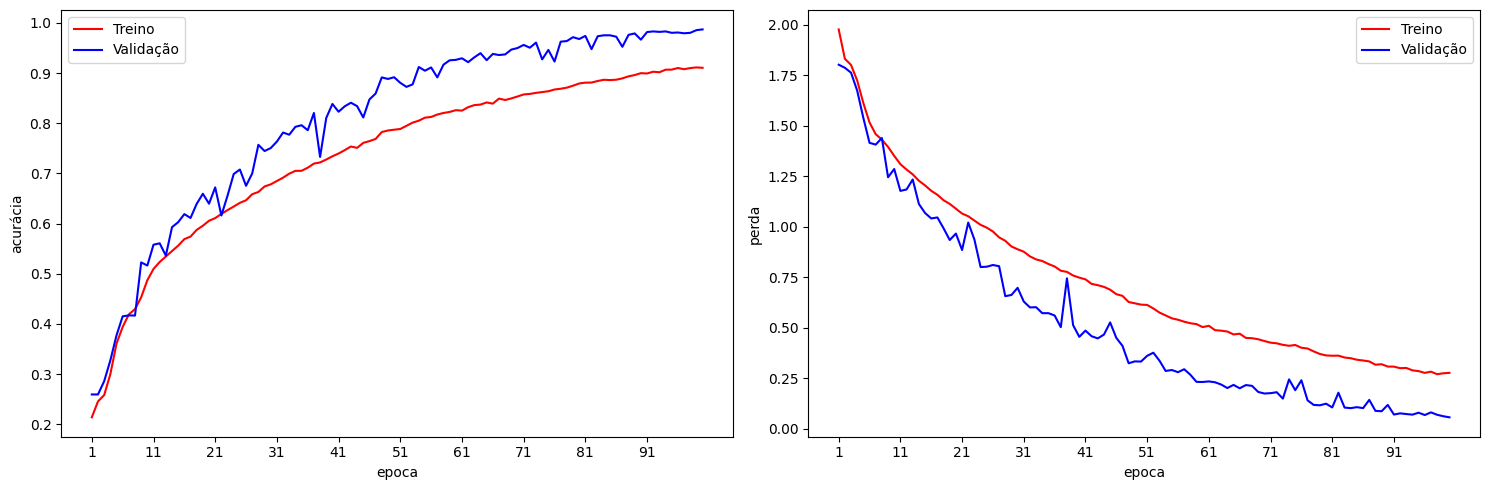

In [14]:
def plota_historico_modelo(historico_modelo):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    num_epochs = len(historico_modelo.history['accuracy'])
    tick_interval = max(1, num_epochs // 10)

    # gráfico de acurácia
    axs[0].plot(range(1, num_epochs + 1), historico_modelo.history['accuracy'], 'r', label='Treino')
    axs[0].plot(range(1, num_epochs + 1), historico_modelo.history['val_accuracy'], 'b', label='Validação')
    axs[0].set_ylabel('acurácia')
    axs[0].set_xlabel('epoca')
    axs[0].set_xticks(np.arange(1, num_epochs + 1, tick_interval))
    axs[0].legend(loc='best')

    # gráfico de perda
    axs[1].plot(range(1, num_epochs + 1), historico_modelo.history['loss'], 'r', label='Treino')
    axs[1].plot(range(1, num_epochs + 1), historico_modelo.history['val_loss'], 'b', label='Validação')
    axs[1].set_ylabel('perda')
    axs[1].set_xlabel('epoca')
    axs[1].set_xticks(np.arange(1, num_epochs + 1, tick_interval))
    axs[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

plota_historico_modelo(history)

In [15]:
scores = model.evaluate(np.array(X_test), np.array(y_test), batch_size=batch_size)
print(f'Teste Acurácia : {scores[1]*100:.2f}%')
print(f'Teste perda: {scores[0]:.4f}')

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6623 - loss: 1.4468
Teste Acurácia : 66.23%
Teste perda: 1.4468


113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


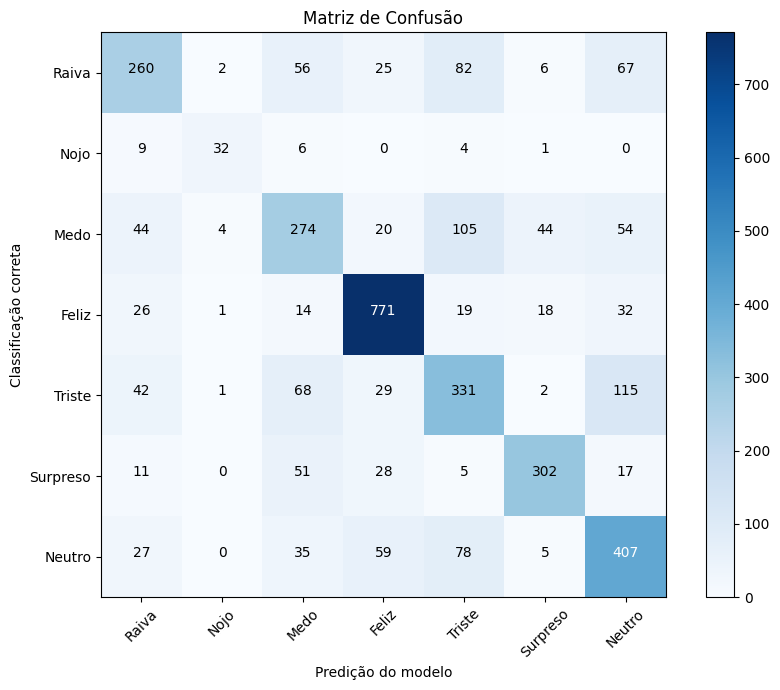

In [16]:
# carrega o melhor modelo
json_file = open(arquivo_modelo_json, 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
loaded_model.load_weights(arquivo_modelo)

y_pred = loaded_model.predict(X_test)
true_y = [np.argmax(y) for y in y_test.tolist()] # índice da emoção real
pred_y = [np.argmax(y) for y in y_pred.tolist()] # índice da emoção prevista

np.save('truey_mod01', true_y)
np.save('predy_mod01', pred_y)

#matriz
cm = confusion_matrix(true_y, pred_y)
titulo = 'Matriz de Confusão'

plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(titulo)
plt.colorbar()
tick_marks = np.arange(len(expressoes))
plt.xticks(tick_marks, expressoes, rotation=45)
plt.yticks(tick_marks, expressoes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.ylabel('Classificação correta')
plt.xlabel('Predição do modelo')
plt.tight_layout()
plt.savefig('matriz_confusao_mod02.png')
plt.show()

In [17]:
acertos_por_emocao = cm.diagonal()
total_por_emocao = cm.sum(axis=1)
acuracia_por_emocao = acertos_por_emocao / total_por_emocao * 100
for emocao, acc in zip(expressoes, acuracia_por_emocao):
    print(f'{emocao}: {acc:.1f}% de acerto')

melhor = expressoes[np.argmax(acuracia_por_emocao)]
pior = expressoes[np.argmin(acuracia_por_emocao)]
print(f'\nmelhor: {melhor}')
print(f'pior: {pior}')

Raiva: 52.2% de acerto
Nojo: 61.5% de acerto
Medo: 50.3% de acerto
Feliz: 87.5% de acerto
Triste: 56.3% de acerto
Surpreso: 72.9% de acerto
Neutro: 66.6% de acerto

melhor: Feliz
pior: Medo


In [18]:
import os

# pasta de imagen
pasta = '/content/gdrive/MyDrive/Imagens'

arquivos = [f for f in os.listdir(pasta) if f.endswith(('.jpeg'))]
face_cascade = cv2.CascadeClassifier('/content/gdrive/MyDrive/haarcascade_frontalface_default (1).xml')

for arquivo in arquivos:

    caminho = os.path.join(pasta, arquivo)
    img = cv2.imread(caminho)


    img_original = img.copy()
    cinza = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY) # converte pra cinza

    faces_encontradas = face_cascade.detectMultiScale(
        cinza,
        scaleFactor=1.1,
        minNeighbors=10, # mais rigoroso pra evitar
        minSize=(60, 60)
    )

    print(f'{len(faces_encontradas)}')

    for (x, y, w, h) in faces_encontradas:
        roi = cinza[y:y + h, x:x + w]
        roi = roi.astype('float') / 255.0
        roi = np.expand_dims(np.expand_dims(cv2.resize(roi, (48, 48)), -1), 0)

        preds = loaded_model.predict(roi, verbose=0)[0]
        confianca = np.max(preds)

        if confianca > 0.50:
            label = expressoes[np.argmax(preds)]
            cv2.putText(img_original, f'{label} ({confianca*100:.0f}%)', (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2, cv2.LINE_AA)
            cv2.rectangle(img_original, (x, y), (x + w, y + h), (0, 0, 255), 2)

    cv2_imshow(img_original)